In [1]:
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdchem
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
import json
import pickle

print("All imports successful")

All imports successful


In [2]:
# atom feature extraction
ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 
              'Br', 'Mg', 'Na', 'Ca', 'Fe', 'As', 'Al', 'I', 
              'B', 'V', 'K', 'Tl', 'Yb', 'Sb', 'Sn', 'Ag', 
              'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H', 'Li', 'Ge', 
              'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr', 'Cr', 
              'Pt', 'Hg', 'Pb', 'other']

HYBRIDIZATION_TYPES = [
    rdchem.HybridizationType.SP,
    rdchem.HybridizationType.SP2,
    rdchem.HybridizationType.SP3,
    rdchem.HybridizationType.SP3D,
    rdchem.HybridizationType.SP3D2
]

def one_hot(value, choices):
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding

def get_atom_features(atom):
    features = []
    # atom type one-hot (44 + 1 = 45)
    features += one_hot(atom.GetSymbol(), ATOM_TYPES)
    # degree (0-10)
    features += one_hot(atom.GetDegree(), list(range(11)))
    # formal charge
    features.append(atom.GetFormalCharge())
    # number of hydrogens
    features += one_hot(atom.GetTotalNumHs(), list(range(9)))
    # is in ring
    features.append(int(atom.IsInRing()))
    # is aromatic
    features.append(int(atom.GetIsAromatic()))
    # hybridization one-hot
    features += one_hot(atom.GetHybridization(), HYBRIDIZATION_TYPES)
    return features

def get_bond_features(bond):
    bond_type = bond.GetBondTypeAsDouble()
    features = [
        int(bond_type == 1.0),   # single
        int(bond_type == 2.0),   # double
        int(bond_type == 3.0),   # triple
        int(bond_type == 1.5),   # aromatic
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]
    return features

# test on aspirin
aspirin = "CC(=O)Oc1ccccc1C(=O)O"
mol = Chem.MolFromSmiles(aspirin)
atom = mol.GetAtomWithIdx(0)
bond = mol.GetBondWithIdx(0)

atom_feat = get_atom_features(atom)
bond_feat = get_bond_features(bond)

print(f"Atom feature vector length: {len(atom_feat)}")
print(f"Bond feature vector length: {len(bond_feat)}")
print(f"\nAspirin: {mol.GetNumAtoms()} atoms, {mol.GetNumBonds()} bonds")
print(f"First atom ({atom.GetSymbol()}) features: {atom_feat}")

Atom feature vector length: 76
Bond feature vector length: 6

Aspirin: 13 atoms, 13 bonds
First atom (C) features: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]


In [3]:
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # node features — one per atom
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(get_atom_features(atom))
    
    x = torch.tensor(atom_features, dtype=torch.float)
    
    # edge indices and features — one per bond (bidirectional)
    edge_indices = []
    edge_features = []
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        feat = get_bond_features(bond)
        
        # add both directions
        edge_indices.append([i, j])
        edge_indices.append([j, i])
        edge_features.append(feat)
        edge_features.append(feat)
    
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr  = torch.tensor(edge_features, dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# test on aspirin
aspirin_smiles = "CC(=O)Oc1ccccc1C(=O)O"
graph = smiles_to_graph(aspirin_smiles)

print(f"Aspirin molecular graph:")
print(f"  Nodes (atoms):     {graph.num_nodes}")
print(f"  Edges (bonds×2):   {graph.num_edges}")
print(f"  Node features:     {graph.x.shape}")
print(f"  Edge features:     {graph.edge_attr.shape}")
print(f"  Edge index shape:  {graph.edge_index.shape}")
print(f"\nGraph object: {graph}")

Aspirin molecular graph:
  Nodes (atoms):     13
  Edges (bonds×2):   26
  Node features:     torch.Size([13, 76])
  Edge features:     torch.Size([26, 6])
  Edge index shape:  torch.Size([2, 26])

Graph object: Data(x=[13, 76], edge_index=[2, 26], edge_attr=[26, 6])


In [5]:
import json
import pickle
import numpy as np

# reload drugs
with open('../data/davis_drugs.txt', 'rb') as f:
    content = f.read().decode('utf-8', errors='ignore')
drugs_dict = json.loads(content)
drugs = list(drugs_dict.values())

# reload affinity
with open('../data/davis_affinity.npy', 'rb') as f:
    affinity = pickle.load(f, encoding='latin1')
affinity = np.array(affinity)

print(f"Drugs loaded: {len(drugs)}")
print(f"Affinity shape: {affinity.shape}")

Drugs loaded: 68
Affinity shape: (68, 442)


C:\Users\hidey\AppData\Local\Temp\ipykernel_37900\942401578.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  affinity = pickle.load(f, encoding='latin1')


C:\Users\hidey\AppData\Local\Temp\ipykernel_37900\920739328.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


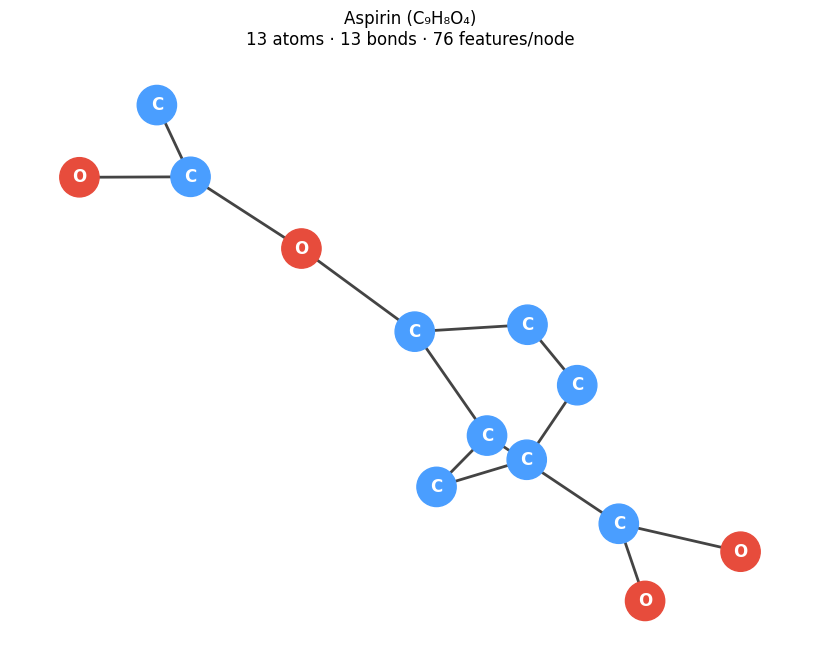

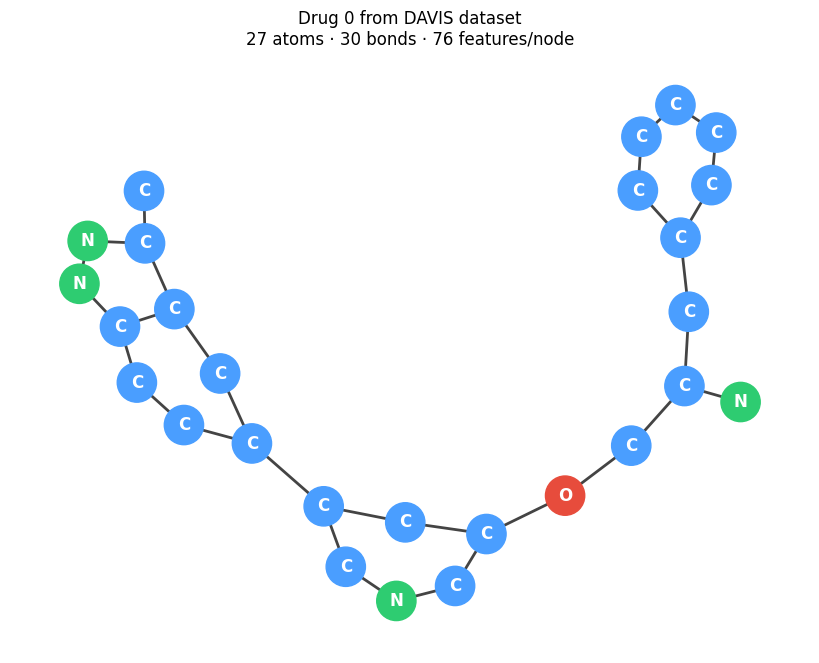

In [6]:
from rdkit.Chem import rdDepictor
rdDepictor.SetPreferCoordGen(True)

def visualize_molecule_graph(smiles, title):
    mol = Chem.MolFromSmiles(smiles)
    graph = smiles_to_graph(smiles)
    
    # convert to networkx for visualization
    G = to_networkx(graph, to_undirected=True)
    
    # get atom symbols for labels
    labels = {i: mol.GetAtomWithIdx(i).GetSymbol() 
              for i in range(mol.GetNumAtoms())}
    
    # color by atom type
    color_map = {
        'C': '#4a9eff', 'N': '#2ecc71', 'O': '#e74c3c',
        'S': '#f1c40f', 'F': '#9b59b6', 'Cl': '#1abc9c'
    }
    colors = [color_map.get(mol.GetAtomWithIdx(i).GetSymbol(), 
              '#888888') for i in range(mol.GetNumAtoms())]
    
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, labels=labels, node_color=colors,
            node_size=800, font_size=12, font_color='white',
            font_weight='bold', edge_color='#444',
            width=2, with_labels=True)
    plt.title(f'{title}\n{mol.GetNumAtoms()} atoms · '
              f'{mol.GetNumBonds()} bonds · '
              f'{graph.x.shape[1]} features/node')
    plt.tight_layout()
    plt.show()

# visualize aspirin
visualize_molecule_graph(
    "CC(=O)Oc1ccccc1C(=O)O", 
    "Aspirin (C₉H₈O₄)"
)

# visualize a drug from the dataset
visualize_molecule_graph(
    drugs[0],
    f"Drug 0 from DAVIS dataset"
)

In [7]:
from torch_geometric.data import Data
from tqdm import tqdm

print("Converting all molecules to graphs...")

graphs = []
valid_indices = []

for i, smiles in enumerate(tqdm(drugs)):
    g = smiles_to_graph(smiles)
    if g is not None:
        graphs.append(g)
        valid_indices.append(i)
    else:
        print(f"  Failed: drug {i} — {smiles[:30]}")

print(f"\nSuccessfully converted: {len(graphs)}/{len(drugs)} molecules")
print(f"\nGraph statistics:")
num_nodes = [g.num_nodes for g in graphs]
num_edges = [g.num_edges for g in graphs]
print(f"  Nodes per molecule: min={min(num_nodes)} "
      f"max={max(num_nodes)} avg={np.mean(num_nodes):.1f}")
print(f"  Edges per molecule: min={min(num_edges)} "
      f"max={max(num_edges)} avg={np.mean(num_edges):.1f}")

Converting all molecules to graphs...


100%|██████████| 68/68 [00:00<00:00, 116.75it/s]


Successfully converted: 68/68 molecules

Graph statistics:
  Nodes per molecule: min=19 max=46 avg=32.1
  Edges per molecule: min=42 max=102 avg=70.9


In [9]:
import pandas as pd
import pickle
import json
import numpy as np

# reload proteins
with open('../data/davis_proteins.txt', 'rb') as f:
    content = f.read().decode('utf-8', errors='ignore')
proteins_dict = json.loads(content)
proteins = list(proteins_dict.values())
# build pairs dataframe
rows = []
for i in range(affinity.shape[0]):
    if i not in valid_indices:
        continue
    for j in range(affinity.shape[1]):
        aff = affinity[i][j]
        label = 1 if aff <= 30 else 0
        rows.append({
            'drug_idx': i,
            'protein_idx': j,
            'affinity': aff,
            'label': label,
            'smiles': drugs[i],
            'protein': proteins[j]
        })

df = pd.DataFrame(rows)

print(f"Total pairs: {len(df)}")
print(f"Positive: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
print(f"Negative: {(1-df['label']).sum()} ({(1-df['label']).mean()*100:.1f}%)")

# save
df.to_csv('../data/dti_pairs.csv', index=False)

# save graphs
import pickle
with open('../data/drug_graphs.pkl', 'wb') as f:
    pickle.dump({'graphs': graphs, 'valid_indices': valid_indices}, f)

print(f"\nSaved dti_pairs.csv and drug_graphs.pkl")

Total pairs: 30056
Positive: 1527 (5.1%)
Negative: 28529 (94.9%)

Saved dti_pairs.csv and drug_graphs.pkl
